In [1]:
%pylab inline

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


In [2]:
from pycbc.waveform.waveform import _mode_array_map
from pycbc.waveform import get_fd_waveform
from pycbc.filter import overlap_cplx, sigma, overlap

In [3]:
approx = "IMRPhenomXHM"
delta_f=0.125
f_lower=20
fh = 512
params = dict(
    mass1=100,
    mass2=10,
    inclination=pi/2,
    delta_f=delta_f,
    f_lower=f_lower,
    f_final=fh,
    approximant=approx
)

In [4]:
lm = ["22", "44"]
hp, hc = get_fd_waveform(**params, mode_array=_mode_array_map(lm, approx))
abs((overlap_cplx(hp, hc)).imag)

0.9925232112445065

In [5]:
from pycbc.psd import aLIGOZeroDetHighPower

In [41]:
length = int(fh / delta_f) + 1
psd = aLIGOZeroDetHighPower(length, delta_f, f_lower)

# check orthogonalization routine

In [42]:
phase = pi/2.1
subdom_lm = "32"
h_dom, _ = get_fd_waveform(**params, coa_phase=phase, mode_array=_mode_array_map("22", approx))
h_sub, _ = get_fd_waveform(**params, coa_phase=phase, mode_array=_mode_array_map(subdom_lm, approx))

In [43]:
abs(max(h_dom.data)), h_dom.data[argmax(abs(h_dom.data))]

(1.1732561378896065e-20, (1.0804071124973355e-20+7.973767367642435e-21j))

In [22]:
abs(max(h_dom.data)), h_dom.data[argmax(abs(h_dom.data))]

(1.1732561378896065e-20, (1.0804071124973355e-20+7.973767367642435e-21j))

In [46]:
phase = 0
subdom_lm = "21"
h_dom, _ = get_fd_waveform(**params, coa_phase = phase, mode_array=_mode_array_map("22", approx))
h_sub, _ = get_fd_waveform(**params, coa_phase = phase, mode_array=_mode_array_map(subdom_lm, approx))

sigma_dom = sigma(h_dom, psd, f_lower, fh)
sigma_sub = sigma(h_sub, psd, f_lower, fh)

if sigma_dom > 0:
    if sigma_sub > 0:
        # generate the orthogonal waveform
        zeta = overlap_cplx(h_dom, h_sub, psd, f_lower, fh, normalized=False)
        zeta = zeta / sigma_dom / sigma_sub
        norm = 1 / (sqrt(1 - abs(zeta) ** 2))
        h_sub_perp = (h_sub / sigma_sub - zeta * h_dom / sigma_dom) * norm
        sigma_sub_perp = sigma_sub / norm
for phase2 in linspace(0,pi/2,10):
    h_dom, _ = get_fd_waveform(**params, coa_phase=phase2, mode_array=_mode_array_map("22", approx))
    h_sub, _ = get_fd_waveform(**params, coa_phase=phase2, mode_array=_mode_array_map(subdom_lm, approx))
    print(abs(overlap_cplx(h_sub, h_dom, psd, f_lower, fh, normalized=False)), abs(zeta), sigma_sub_perp, sigma_sub)
    print(abs(overlap_cplx(h_sub_perp, h_dom, psd, f_lower, fh, normalized=False)), abs(zeta), sigma_sub_perp, sigma_sub)
    print(abs(overlap_cplx(h_sub_perp, h_sub+h_dom, psd, f_lower, fh, normalized=False)), abs(zeta), sigma_sub_perp, sigma_sub)

11254248.773505235 0.3366855808581146 2992.7610479395075 3178.3205215429616
2.8573558503773083e-13 0.3366855808581146 2992.7610479395075 3178.3205215429616
2992.761047939506 0.3366855808581146 2992.7610479395075 3178.3205215429616
11254248.773505237 0.3366855808581146 2992.7610479395075 3178.3205215429616
2.8899830891291594e-13 0.3366855808581146 2992.7610479395075 3178.3205215429616
2992.7610479395066 0.3366855808581146 2992.7610479395075 3178.3205215429616
11254248.773505237 0.3366855808581146 2992.7610479395075 3178.3205215429616
2.2484467549026577e-13 0.3366855808581146 2992.7610479395075 3178.3205215429616
2992.7610479395057 0.3366855808581146 2992.7610479395075 3178.3205215429616
11254248.773505235 0.3366855808581146 2992.7610479395075 3178.3205215429616
3.6347419445565763e-13 0.3366855808581146 2992.7610479395075 3178.3205215429616
2992.761047939506 0.3366855808581146 2992.7610479395075 3178.3205215429616
11254248.773505235 0.3366855808581146 2992.7610479395075 3178.320521542961

In [32]:
sum(h_sub_perp.data * h_sub_perp.data.conjugate() * h_sub_perp.delta_f)

(1257.5943123724896+0j)

In [33]:
sigma(h_sub_perp, psd, f_lower, fh)

ValueError: For C2C FFT, len(outvec) must be nbatch*size

In [37]:
sigma(h_sub/sigma_sub, psd, f_lower, fh)

0.9703640890140275

In [38]:
zeta

(-0.06600907997761352-0.09793462860613307j)

In [39]:
phase = 0
subdom_lm = "21"
psd=None
h_dom, _ = get_td_waveform(**{key:v for key,v in params.items() if key not in ["approximant", "delta_f"]}, 
                           approximant="SEOBNRv4HM", delta_t=0.001,
                           coa_phase = phase, mode_array=_mode_array_map("22", approx))
h_sub, _ = get_td_waveform(**{key:v for key,v in params.items() if key not in ["approximant", "delta_f"]}, 
                           approximant="SEOBNRv4HM", delta_t=0.001,
                           coa_phase = phase, mode_array=_mode_array_map(subdom_lm, approx))

sigma_dom = sigma(h_dom, psd, f_lower, fh)
sigma_sub = sigma(h_sub, psd, f_lower, fh)

if sigma_dom > 0:
    if sigma_sub > 0:
        # generate the orthogonal waveform
        zeta = overlap_cplx(h_dom, h_sub, psd, f_lower, fh, normalized=False)
        zeta = zeta / sigma_dom / sigma_sub
        norm = 1 / (sqrt(1 - abs(zeta) ** 2))
        h_sub_perp = (h_sub / sigma_sub - zeta * h_dom / sigma_dom) * norm
        sigma_sub_perp = sigma_sub / norm
for phase2 in linspace(0,pi/2,10):
    h_dom, _ = get_fd_waveform(**params, coa_phase=phase2, mode_array=_mode_array_map("22", approx))
    h_sub, _ = get_fd_waveform(**params, coa_phase=phase2, mode_array=_mode_array_map(subdom_lm, approx))
    print(abs(overlap_cplx(h_sub, h_dom, psd, f_lower, fh, normalized=False)), abs(zeta), sigma_sub_perp, sigma_sub)
    print(abs(overlap_cplx(h_sub_perp, h_dom, psd, f_lower, fh, normalized=False)), abs(zeta), sigma_sub_perp, sigma_sub)
    print(abs(overlap_cplx(h_sub_perp, h_sub, psd, f_lower, fh, normalized=False)), abs(zeta), sigma_sub_perp, sigma_sub)

1.3705616972901127e-40 0.11810330274684191 1.6370536965679888e-20 1.648591671793169e-20
1.3705616972901125e-40 0.11810330274684191 1.6370536965679888e-20 1.648591671793169e-20
1.3705616972901125e-40 0.11810330274684191 1.6370536965679888e-20 1.648591671793169e-20
1.3705616972901125e-40 0.11810330274684191 1.6370536965679888e-20 1.648591671793169e-20
1.3705616972901125e-40 0.11810330274684191 1.6370536965679888e-20 1.648591671793169e-20
1.3705616972901125e-40 0.11810330274684191 1.6370536965679888e-20 1.648591671793169e-20
1.3705616972901125e-40 0.11810330274684191 1.6370536965679888e-20 1.648591671793169e-20
1.3705616972901125e-40 0.11810330274684191 1.6370536965679888e-20 1.648591671793169e-20
1.3705616972901125e-40 0.11810330274684191 1.6370536965679888e-20 1.648591671793169e-20
1.3705616972901127e-40 0.11810330274684191 1.6370536965679888e-20 1.648591671793169e-20


(-0.1, 0.05)

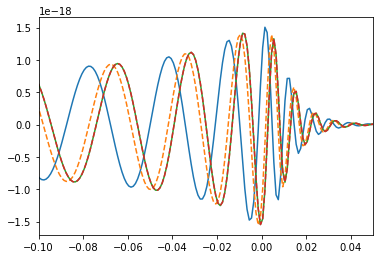

In [10]:
# phi = linspace(0,2*pi,100)
# A22 = 1
# A33 = 0.5
# t = linspace(0, 2*pi, 100)
# h22 = cos(2*t)*A22*(cos)
# h33 = cos(3*t)
from pycbc.waveform import get_td_waveform, td_approximants

hp, hc = get_td_waveform(
#     inclination=pi/2.1,
    mass1=100, mass2=50, approximant="SEOBNRv2_opt", delta_t=0.001, f_lower=10, coa_phase=0)
hp2, hc2 = get_td_waveform(
#     inclination=pi/2.1,
    mass1=100, mass2=50, approximant="SEOBNRv2_opt", delta_t=0.001, f_lower=10, coa_phase=-pi/4)
hp3, hc3 = get_td_waveform(
#     inclination=pi/2.1,
    mass1=100, mass2=50, approximant="SEOBNRv2_opt", delta_t=0.001, f_lower=10, coa_phase=-pi/3)
hp4 =1*( sin(2*pi/3)*hp2 + cos(2*pi/3)*hp )
hp.plot()
# hc.plot()
hp2.plot(ls="--")
hp3.plot()
hp4.plot(ls="--")
xlim(-0.1, 0.05)